In [160]:
import pandas as pd 
import numpy as np
import statsmodels
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter 
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, acf, pacf
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss
from sklearn.metrics import brier_score_loss, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.metrics import balanced_accuracy_score, brier_score_loss, accuracy_score, roc_auc_score, roc_curve, classification_report
from sklearn.model_selection import KFold
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler, OneHotEncoder 
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

In [12]:
import pickle
import numpy as np 

In [16]:
pip install numpy 

Note: you may need to restart the kernel to use updated packages.


In [33]:
file_path = '/Users/akirakuno/Downloads/DONT_DELETE_ME_KUT_29_comma_separated.csv' 


In [73]:
df = pd.read_csv(file_path) 
df.head() 

,file_id,speech_id,speaker_name,speaker_party,gender,speech_text,jaar,date,kamer,category,...,coalition_status,word_count,normalized_title,text_length,duration,energy,raw,is_timeout,power-samples,result
0,h-tk-20152016-28-23,SPEECH_124,De heer Voordewind,CU,Man,Voorzitter. Mijn stemverklaring betreft de mot...,2015-2016,2015-11-24,tk,handelingen,...,opposition,128.0,Stemmingen moties Begroting Buitenlandse Zaken,798,51.076996,3511.159047,"{'message': {'content': '```json\n{\n ""mentio...",False,NaN,NaN
1,h-tk-20152016-28-23,SPEECH_142,De heer Ten Broeke,VVD,Man,Nu mijn motie op stuk nr. 22 die is medeondert...,2015-2016,2015-11-24,tk,handelingen,...,coalition,44.0,Stemmingen moties Begroting Buitenlandse Zaken,232,31.702709,2047.306269,"{'message': {'content': '```json\n{\n ""mentio...",False,"[64.17, 49.21, 37.86, 35.09, 35.33, 35.96, 36....","{'mentions': [{'name': 'Van Bommel', 'type': '..."
2,h-tk-20152016-31-16,SPEECH_725,De heer Oskam,CDA,Man,Ik ben erg blij met het openblijven van de rec...,2015-2016,2015-12-01,tk,handelingen,...,opposition,91.0,Stemmingen moties Begroting Veiligheid en Just...,505,22.749242,1503.037007,"{'message': {'content': '```json\n{\n ""mentio...",False,"[56.77, 40.21, 35.61, 36.06, 38.07, 39.52, 38....","{'mentions': [{'name': 'staatssecretaris', 'ty..."
3,h-tk-20152016-31-16,SPEECH_735,Mevrouw Kuiken,PvdA,Woman,Voorzitter. Wij hebben verzuimd om te stemmen ...,2015-2016,2015-12-01,tk,handelingen,...,coalition,18.0,Stemmingen moties Begroting Veiligheid en Just...,107,20.224849,1282.475025,"{'message': {'content': '```json\n{\n ""mentio...",False,NaN,NaN
4,h-tk-20152016-31-16,SPEECH_759,De heer Van Vliet,Van Vliet,Man,Ik wil de heer Pechtold graag nog een tijdje t...,2015-2016,2015-12-01,tk,handelingen,...,opposition,28.0,Stemmingen moties Begroting Veiligheid en Just...,146,25.088281,1527.494010,"{'message': {'content': '```json\n{\n ""mentio...",False,NaN,NaN


In [75]:
df.columns

Index(['file_id', 'speech_id', 'speaker_name', 'speaker_party', 'gender',
       'speech_text', 'jaar', 'date', 'kamer', 'category', 'title',
       'document_number', 'url', 'meta_url', 'vergadernummer',
       'standardized_name', 'date_of_birth', 'seniority_days',
       'coalition_status', 'word_count', 'normalized_title', 'text_length',
       'duration', 'energy', 'raw', 'is_timeout', 'power-samples', 'result'],
      dtype='object')

In [77]:
df.isnull().sum() 

file_id                  0
speech_id                0
speaker_name             1
speaker_party          479
gender                   1
speech_text              0
jaar                     0
date                     0
kamer                    0
category                 0
title                    0
document_number      74316
url                      0
meta_url                 0
vergadernummer           0
standardized_name        1
date_of_birth          479
seniority_days           1
coalition_status       479
word_count               0
normalized_title         0
text_length              0
duration                39
energy                  50
raw                      0
is_timeout               0
power-samples        65934
result               65934
dtype: int64

In [82]:
df = df.drop(['document_number', 'power-samples', 'result'], axis=1)

In [84]:
df = df.dropna() 

In [86]:
df.isnull().sum() 

file_id              0
speech_id            0
speaker_name         0
speaker_party        0
gender               0
speech_text          0
jaar                 0
date                 0
kamer                0
category             0
title                0
url                  0
meta_url             0
vergadernummer       0
standardized_name    0
date_of_birth        0
seniority_days       0
coalition_status     0
word_count           0
normalized_title     0
text_length          0
duration             0
energy               0
raw                  0
is_timeout           0
dtype: int64

In [92]:
 # Check for ad hominem attacks by looking for "count": 1 or higher (not "count": 0)
ad_hominem_count = df['raw'].str.contains(r'"count":\s*[1-9]\d*', na=False, regex=True).sum()
print(ad_hominem_count) 

11893


In [98]:
mask = df['raw'].str.contains(r'"count":\s*[1-9]\d*', na=False, regex=True)


df['ad_hominem_flag'] = mask.astype(int)

In [231]:
df['ad_hominem_flag'].value_counts() 

ad_hominem_flag
0    61894
1    11893
Name: count, dtype: int64

In [100]:
df.head() 

,file_id,speech_id,speaker_name,speaker_party,gender,speech_text,jaar,date,kamer,category,...,seniority_days,coalition_status,word_count,normalized_title,text_length,duration,energy,raw,is_timeout,ad_hominem_flag
0,h-tk-20152016-28-23,SPEECH_124,De heer Voordewind,CU,Man,Voorzitter. Mijn stemverklaring betreft de mot...,2015-2016,2015-11-24,tk,handelingen,...,3282.0,opposition,128.0,Stemmingen moties Begroting Buitenlandse Zaken,798,51.076996,3511.159047,"{'message': {'content': '```json\n{\n ""mentio...",False,0
1,h-tk-20152016-28-23,SPEECH_142,De heer Ten Broeke,VVD,Man,Nu mijn motie op stuk nr. 22 die is medeondert...,2015-2016,2015-11-24,tk,handelingen,...,3282.0,coalition,44.0,Stemmingen moties Begroting Buitenlandse Zaken,232,31.702709,2047.306269,"{'message': {'content': '```json\n{\n ""mentio...",False,0
2,h-tk-20152016-31-16,SPEECH_725,De heer Oskam,CDA,Man,Ik ben erg blij met het openblijven van de rec...,2015-2016,2015-12-01,tk,handelingen,...,1168.0,opposition,91.0,Stemmingen moties Begroting Veiligheid en Just...,505,22.749242,1503.037007,"{'message': {'content': '```json\n{\n ""mentio...",False,0
3,h-tk-20152016-31-16,SPEECH_735,Mevrouw Kuiken,PvdA,Woman,Voorzitter. Wij hebben verzuimd om te stemmen ...,2015-2016,2015-12-01,tk,handelingen,...,3179.0,coalition,18.0,Stemmingen moties Begroting Veiligheid en Just...,107,20.224849,1282.475025,"{'message': {'content': '```json\n{\n ""mentio...",False,0
4,h-tk-20152016-31-16,SPEECH_759,De heer Van Vliet,Van Vliet,Man,Ik wil de heer Pechtold graag nog een tijdje t...,2015-2016,2015-12-01,tk,handelingen,...,1994.0,opposition,28.0,Stemmingen moties Begroting Veiligheid en Just...,146,25.088281,1527.494010,"{'message': {'content': '```json\n{\n ""mentio...",False,0


In [111]:
df.columns 

Index(['file_id', 'speech_id', 'speaker_name', 'speaker_party', 'gender',
       'speech_text', 'jaar', 'date', 'kamer', 'category', 'title', 'url',
       'meta_url', 'vergadernummer', 'standardized_name', 'date_of_birth',
       'seniority_days', 'coalition_status', 'word_count', 'normalized_title',
       'text_length', 'duration', 'energy', 'raw', 'is_timeout',
       'ad_hominem_flag'],
      dtype='object')

In [303]:
df['normalized_title'].value_counts()

normalized_title
Begroting Volksgezondheid, Welzijn en Sport                                                                                               6855
Begroting Onderwijs, Cultuur en Wetenschap                                                                                                6624
Begroting Sociale Zaken en Werkgelegenheid                                                                                                6427
Begroting Justitie en Veiligheid                                                                                                          5489
Begroting Buitenlandse Zaken                                                                                                              5384
                                                                                                                                          ... 
Stemmingen Incidentele suppletoire begroting inzake Herstel Toeslagen                                                        

In [260]:
X = df[['speaker_party', 'gender', 'seniority_days', 'coalition_status', 'word_count', 'normalized_title']] 


In [262]:
Y = df[['ad_hominem_flag']]

In [264]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

In [266]:
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)

X_test  = X_test.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

In [270]:
categorical_cols = ['speaker_party', 'gender', 'coalition_status', 'normalized_title'] 
numeric_cols = ['seniority_days', 'word_count'] 


In [272]:
num_imputer = SimpleImputer(strategy='median') 

X_train_numeric = X_train[numeric_cols] 
X_train_numeric_imputed = pd.DataFrame(
    num_imputer.fit_transform(X_train_numeric),
    columns=numeric_cols,
    index=X_train.index
) 

X_test_numeric = X_test[numeric_cols]
X_test_numeric_imputed = pd.DataFrame(
    num_imputer.transform(X_test_numeric),
    columns=numeric_cols,
    index=X_test.index
)

In [274]:
# --- (2) Scaling immediately after imputation ---
scaler = StandardScaler()

# Fit scaler on the *imputed* training data, then transform
X_train_numeric_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_numeric_imputed),
    columns = numeric_cols,
    index   = X_train_numeric_imputed.index
)

# Only transform the test side
X_test_numeric_scaled  = pd.DataFrame(
    scaler.transform(X_test_numeric_imputed),
    columns = numeric_cols,
    index   = X_test_numeric_imputed.index
)

In [276]:
X_train_pre = pd.concat(
    [X_train_numeric_scaled, X_train[categorical_cols]],
    axis=1
)
X_test_pre = pd.concat(
    [X_test_numeric_scaled, X_test[categorical_cols]],
    axis=1
)

In [278]:
X_train_encoded = pd.get_dummies(
    X_train_pre, 
    columns = categorical_cols, 
    drop_first=True
)

X_test_encoded = pd.get_dummies(
    X_test_pre, 
    columns = categorical_cols, 
    drop_first=True
)

X_test_encoded = X_test_encoded.reindex(
    columns = X_train_encoded.columns,
    fill_value = 0
)

In [280]:
model = LogisticRegression(random_state = 42, max_iter=1000) 
model.fit(X_train_encoded, y_train)
y_pred = model.predict(X_test_encoded)  # No more “missing feature” errors


/Users/akirakuno/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [283]:
accuracy = accuracy_score(y_test, y_pred) 
print(f"Accuracy: {accuracy:.4f}") 


Accuracy: 0.8479


In [285]:
cm = confusion_matrix(y_test, y_pred, labels=[1, 0]) 

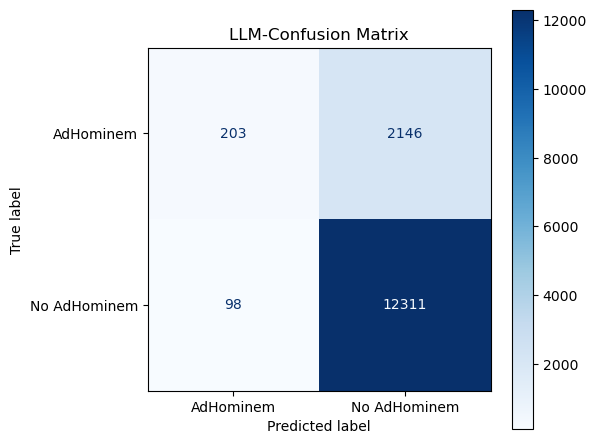

In [287]:
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels    = ['AdHominem', 'No AdHominem']
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', values_format='d', ax=ax)

ax.set_title('LLM-Confusion Matrix')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
plt.tight_layout()
plt.show()


In [289]:
print(classification_report(y_test, y_pred, digits=2)) 

              precision    recall  f1-score   support

           0       0.85      0.99      0.92     12409
           1       0.67      0.09      0.15      2349

    accuracy                           0.85     14758
   macro avg       0.76      0.54      0.53     14758
weighted avg       0.82      0.85      0.79     14758



In [291]:
smote = SMOTE(random_state = 42) 
X_train_res, y_train_res = smote.fit_resample(X_train_encoded, y_train) 

In [340]:
clf = LogisticRegression(max_iter = 1000) 
clf.fit(X_train_res, y_train_res)
y_pred_smote = clf.predict(X_test_encoded)

/Users/akirakuno/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [342]:
accuracy = accuracy_score(y_test, y_pred_smote) 
print(f"Accuracy: {accuracy:.4f}") 


Accuracy: 0.7143


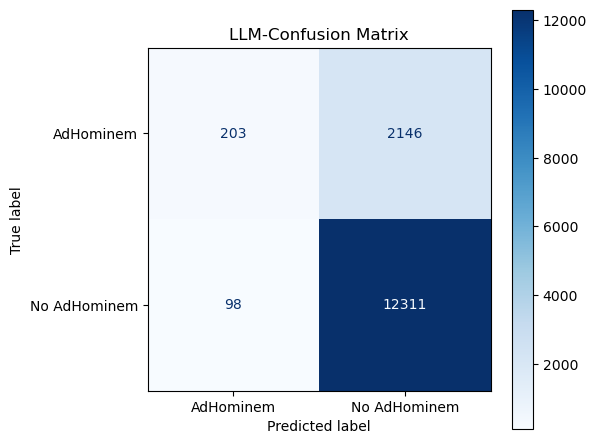

In [344]:
cm = confusion_matrix(y_test, y_pred, labels=[1, 0]) 
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels    = ['AdHominem', 'No AdHominem']
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', values_format='d', ax=ax)

ax.set_title('LLM-Confusion Matrix')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
plt.tight_layout()
plt.show()


In [346]:
print(classification_report(y_test, y_pred_smote, digits=2)) 

              precision    recall  f1-score   support

           0       0.90      0.74      0.81     12409
           1       0.30      0.59      0.40      2349

    accuracy                           0.71     14758
   macro avg       0.60      0.66      0.60     14758
weighted avg       0.81      0.71      0.75     14758



In [348]:
coefficients = clf.coef_[0]
feature_names = X_train_res.columns

In [356]:
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values('Abs_Coefficient', ascending=False)

feature_importance.head(50) 

,Feature,Coefficient,Abs_Coefficient
52,normalized_title_Begroting Defensie (inclusief...,3.785838,3.785838
47,normalized_title_Begroting Binnenlandse Zaken ...,3.669176,3.669176
88,normalized_title_Begrotingen Algemene Zaken en...,3.624780,3.624780
84,normalized_title_Begroting Veiligheid en Justitie,3.567548,3.567548
41,normalized_title_Begroting Algemene Zaken en b...,3.502348,3.502348
66,normalized_title_Begroting Infrastructuur en M...,3.492330,3.492330
60,normalized_title_Begroting Economische Zaken (...,3.480696,3.480696
92,normalized_title_Incidentele suppletoire begro...,3.470413,3.470413
59,normalized_title_Begroting Economische Zaken (...,3.451948,3.451948
87,normalized_title_Begroting Wonen en Rijksdienst,3.448021,3.448021


In [217]:

df_hom1 = df[df['ad_hominem_flag'] == 1]

df_hom1 = df_hom1[['date', 'jaar', 'ad_hominem_flag']].copy()

df_hom1 = df_hom1.reset_index(drop=True)


print(df_hom1.head())

         date       jaar  ad_hominem_flag
0  2015-11-25  2015-2016                1
1  2015-11-25  2015-2016                1
2  2015-11-25  2015-2016                1
3  2015-11-25  2015-2016                1
4  2015-11-25  2015-2016                1


In [219]:
df_hom1['date'] = pd.to_datetime(df_hom1['date']) 

In [221]:
df_hom1 = df_hom1.set_index('date') 

monthly_count = df_hom1['ad_hominem_flag'].resample('M').count() 
print(monthly_count.head()) 

date
2014-10-31    506
2014-11-30    849
2014-12-31      1
2015-01-31      0
2015-02-28      0
Freq: ME, Name: ad_hominem_flag, dtype: int64


/var/folders/kn/208w6lyn7d3gzc9jp41pk7b00000gn/T/ipykernel_31360/864357598.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_count = df_hom1['ad_hominem_flag'].resample('M').count()


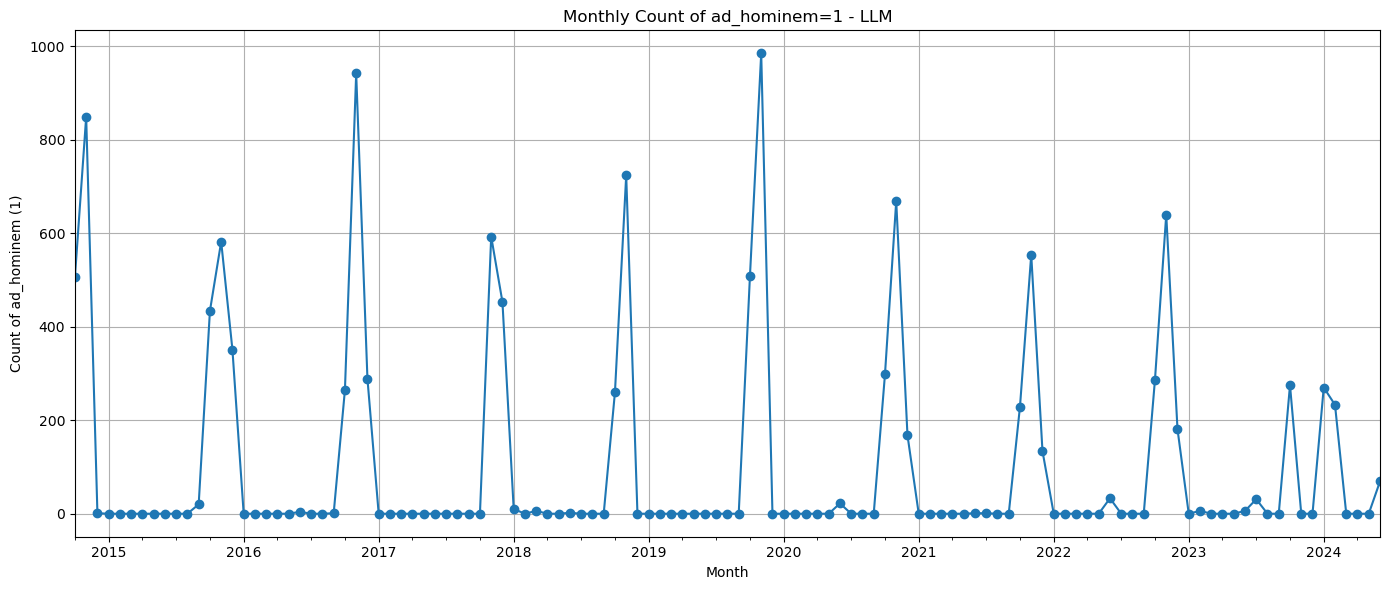

In [226]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
monthly_count.plot(marker='o', linestyle='-')
plt.title('Monthly Count of ad_hominem=1 - LLM')
plt.xlabel('Month')
plt.ylabel('Count of ad_hominem (1)')
plt.grid(True)
plt.tight_layout()
plt.show()


In [238]:
monthly_count.head() 

date
2014-10-31    506
2014-11-30    849
2014-12-31      1
2015-01-31      0
2015-02-28      0
Freq: ME, Name: ad_hominem_flag, dtype: int64

In [241]:
from statsmodels.tsa.stattools import adfuller 
adf_result = adfuller(monthly_count.dropna())

adf_output = pd.Series(adf_result[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
for key, value in adf_result[4].items():
    adf_output[f'Critical Value ({key})'] = value

adf_output

Test Statistic                  -2.805173
p-value                          0.057539
#Lags Used                      11.000000
Number of Observations Used    105.000000
Critical Value (1%)             -3.494220
Critical Value (5%)             -2.889485
Critical Value (10%)            -2.581676
dtype: float64

the ADF test is inconclusive at 5 % but suggests rejecting a unit root at 10 %. It’s a borderline case—if you require strong evidence, treat it as non-stationary; if you allow a 10 % risk, you may proceed as (trend-)stationary.

In [248]:
df_monthly = monthly_count.reset_index(name='count_1')
df_monthly.head() 

,date,count_1
0,2014-10-31,506
1,2014-11-30,849
2,2014-12-31,1
3,2015-01-31,0
4,2015-02-28,0


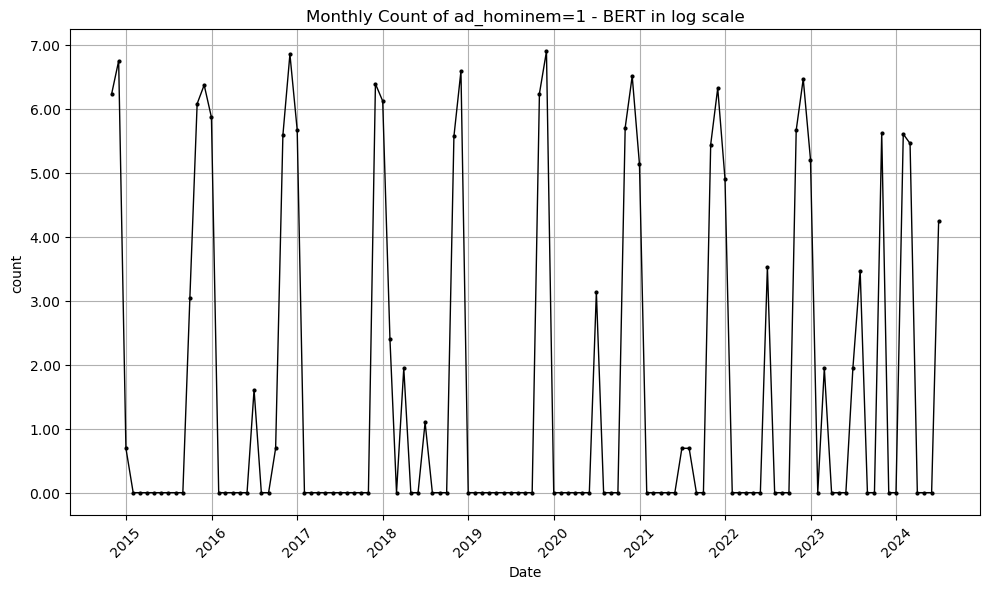

In [306]:
df_monthly['log_count_1'] = np.log(df_monthly['count_1']+1)
# Plot the time series data
plt.figure(figsize=(10, 6))
plt.plot(df_monthly['date'], df_monthly['log_count_1'], marker='o', linestyle='-', color='black',markersize = 2,linewidth=1)
plt.title('Monthly Count of ad_hominem=1 - BERT in log scale')
plt.xlabel('Date')
plt.ylabel('count')
plt.grid(True)
# Manually format y-axis labels to avoid scientific notation
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: '{:.2f}'.format(x)))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

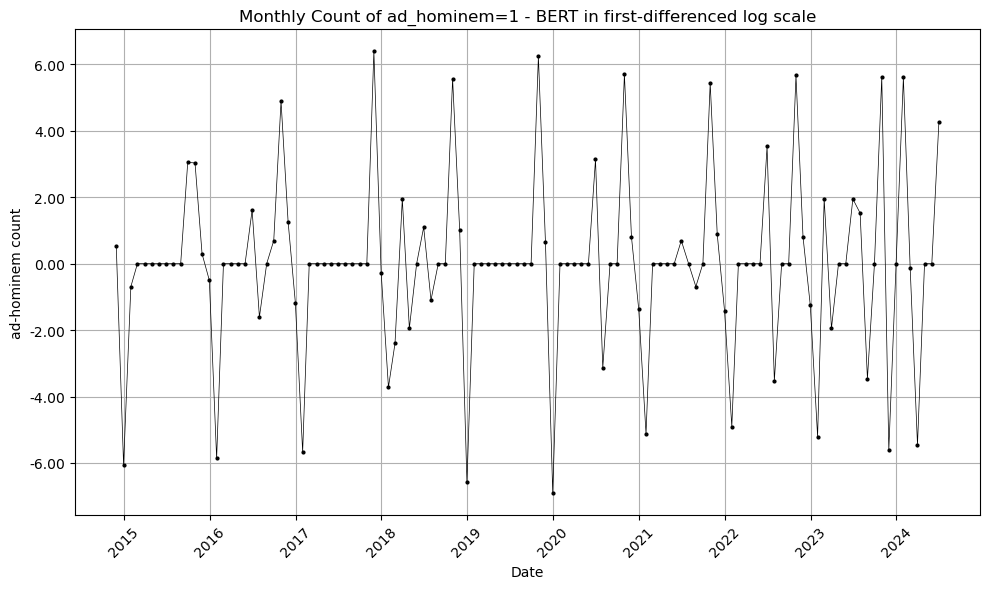

In [320]:
df_monthly['log_count_diff'] = df_monthly['log_count_1'].diff()

# Plotting the first difference of the log-transformed series
plt.figure(figsize=(10, 6))
plt.plot(df_monthly['date'], df_monthly['log_count_diff'], marker='o', linestyle='-', color='black', markersize=2,linewidth=0.5)
plt.title('Monthly Count of ad_hominem=1 - BERT in first-differenced log scale')
plt.xlabel('Date')
plt.ylabel('ad-hominem count')
plt.grid(True)
# Manually format y-axis labels to avoid scientific notation
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: '{:.2f}'.format(x)))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [313]:

from statsmodels.tsa.stattools import adfuller 
adf_result = adfuller(df_monthly['log_count_diff'].dropna())

adf_output = pd.Series(adf_result[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
for key, value in adf_result[4].items():
    adf_output[f'Critical Value ({key})'] = value

adf_output

Test Statistic                -7.890978e+00
p-value                        4.437442e-12
#Lags Used                     1.200000e+01
Number of Observations Used    1.030000e+02
Critical Value (1%)           -3.495493e+00
Critical Value (5%)           -2.890037e+00
Critical Value (10%)          -2.581971e+00
dtype: float64

In [323]:
from pmdarima import auto_arima 
model = auto_arima(df_monthly['log_count_1'], start_p=0, start_q=0,
                   test='adf',       # Use adf test to find optimal 'd'
                   max_p=5, max_q=5, # Maximum p and q
                   m=1,              # Frequency of the series
                   d=1,           # Let the model determine 'd'
                   seasonal=False,   # No Seasonality
                   start_P=0, 
                   D=0, 
                   trace=True,
                   error_action='ignore',  
                   suppress_warnings=True, 
                   stepwise=True)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=554.344, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=556.296, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=556.202, Time=0.01 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=552.349, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.05 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 0.098 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  117
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -275.175
Date:                Mon, 02 Jun 2025   AIC                            552.349
Time:                        00:47:03   BIC                            555.103
Sample:                             0   HQIC                           553.467
                                - 117                                         
Covari

In [328]:
# Extract the selected model order
order = model.order


model = ARIMA(df_monthly['log_count_1'], order=order)
model_fit = model.fit()

forecast = model_fit.get_forecast(steps=12)

/var/folders/kn/208w6lyn7d3gzc9jp41pk7b00000gn/T/ipykernel_31360/2012471257.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_dates = pd.date_range(start=df_monthly['date'].iloc[-1] + pd.Timedelta(days=1), periods=12, freq = 'M')


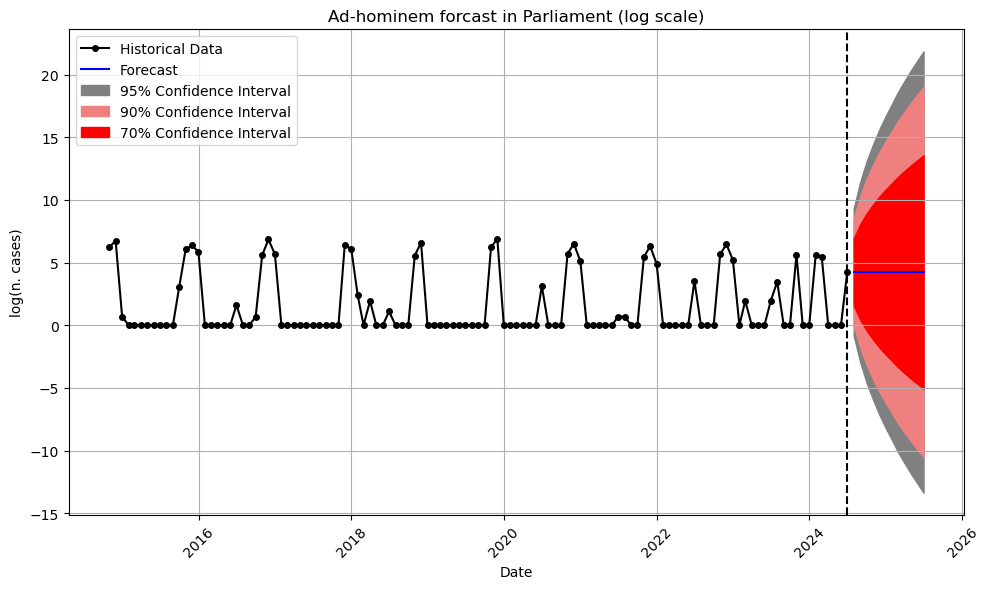

In [331]:
#Extract the forecast mean and confidence intervals
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int(alpha = 0.05) # 95% confidence interval

# Calculate the 70% and 90% confidence intervals
conf_int_70 = forecast.conf_int(alpha = 0.3)  # 70% confidence interval
conf_int_90 = forecast.conf_int(alpha = 0.1)  # 90% confidence interval

# Convert forecast index to match the dates if necessary
forecast_dates = pd.date_range(start=df_monthly['date'].iloc[-1] + pd.Timedelta(days=1), periods=12, freq = 'M')


# Plot the historical data
plt.figure(figsize=(10, 6))
plt.plot(df_monthly['date'], df_monthly['log_count_1'], marker='o', linestyle='-', color='black', markersize=4, label='Historical Data')

# Plot the forecast
plt.plot(forecast_dates, forecast_mean, color='blue', label='Forecast')

# Plot the confidence intervals
plt.fill_between(forecast_dates, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='grey', alpha=1, label='95% Confidence Interval')
plt.fill_between(forecast_dates, conf_int_90.iloc[:, 0], conf_int_90.iloc[:, 1], color='lightcoral', alpha=1, label='90% Confidence Interval')
plt.fill_between(forecast_dates, conf_int_70.iloc[:, 0], conf_int_70.iloc[:, 1], color='red', alpha=1, label='70% Confidence Interval')

# Delineate the start of the forecast with a solid black line
plt.axvline(x=df_monthly['date'].iloc[-1], color='black', linestyle='--')

plt.title('Ad-hominem forcast in Parliament (log scale)')
plt.xlabel('Date')
plt.ylabel('log(n. cases)')
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()